In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#============================================
#Step 1:Import libraries
#============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Set a consistent style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
#================================================
#Step 2:Load and Prepare the Data
#================================================

print("--- Loading and Preparing Data ---")
# 1. Use the new file name
file_path = "/content/drive/MyDrive/diabetes_data_pre_processed.csv"
df = pd.read_csv(file_path)

# 2. Define the target variable (what we want to predict)
y = df['diabetes']

# 3. Define the features (what we use to make the prediction)
#    We will select ONLY the original columns
features_to_use = [
    'gender',
    'age',
    'hypertension',
    'heart_disease',
    'smoking_history',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]
X = df[features_to_use]

print("--- Data Loaded Successfully ---")
print("Features (X) head:")
print(X.head())

--- Loading and Preparing Data ---
--- Data Loaded Successfully ---
Features (X) head:
   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0       0  80.0             0              1                4  25.19   
1       0  54.0             0              0                0  27.32   
2       1  28.0             0              0                4  27.32   
3       0  36.0             0              0                1  23.45   
4       1  76.0             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  
0          6.6                  140  
1          6.6                   80  
2          5.7                  158  
3          5.0                  155  
4          4.8                  155  


In [7]:
#===========================================
#Step 3:Split Data into Training and Test Sets
#===========================================

print("\n--- Splitting Data ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


--- Splitting Data ---
Training set shape: (137427, 8)
Testing set shape: (34357, 8)


In [8]:
#==================================================
#Step 4:Model 1 - Baseline Decision Tree
#==================================================

print("\n--- Model 1: Baseline Decision Tree ---")
baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)
y_pred_baseline = baseline_dt.predict(X_test)

# Store the accuracy for our final comparison
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Model Accuracy: {accuracy_baseline * 100:.2f}%")
print("Baseline Model Classification Report:")
print(classification_report(y_test, y_pred_baseline))


--- Model 1: Baseline Decision Tree ---
Baseline Model Accuracy: 98.67%
Baseline Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     17179
           1       0.97      1.00      0.99     17178

    accuracy                           0.99     34357
   macro avg       0.99      0.99      0.99     34357
weighted avg       0.99      0.99      0.99     34357



In [9]:
#=========================================================
#Step 5:Hyperparameter Tuning with GridSearchCV
#=========================================================

print("\n--- Model 2: Tuned Decision Tree (GridSearchCV) ---")
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1, # Use all available CPU cores
    verbose=1  # Show progress
)

# This step might take a minute or two
grid_search.fit(X_train, y_train)

# This is your final, best model
best_dt = grid_search.best_estimator_

print(f"\nBest Hyperparameters found:")
print(grid_search.best_params_)


--- Model 2: Tuned Decision Tree (GridSearchCV) ---
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Hyperparameters found:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}



--- Final Tuned Model Evaluation ---
Tuned Model Accuracy: 89.63%
Tuned Model AUC Score: 0.9692

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89     17179
           1       0.87      0.94      0.90     17178

    accuracy                           0.90     34357
   macro avg       0.90      0.90      0.90     34357
weighted avg       0.90      0.90      0.90     34357


Plotting Tuned Model Confusion Matrix...


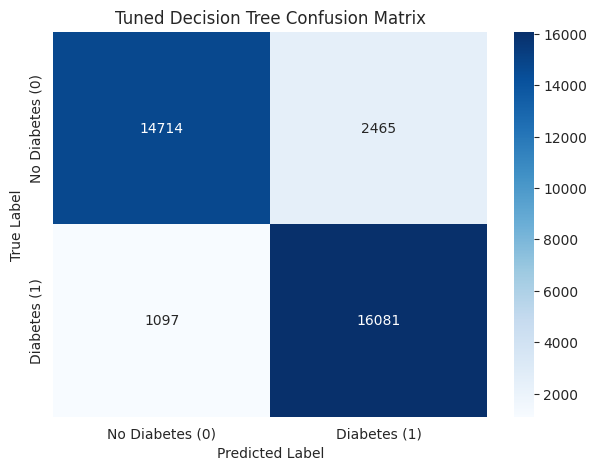


Plotting ROC-AUC Curve...


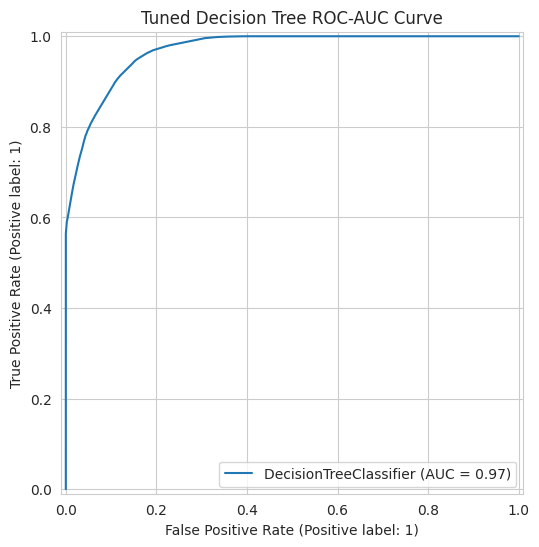

In [10]:
#==============================================
#Step 6:Evaluate the Best Tuned Model
#==============================================

print("\n--- Final Tuned Model Evaluation ---")
y_pred_tuned = best_dt.predict(X_test)
y_pred_proba_tuned = best_dt.predict_proba(X_test)[:, 1]

# Store metrics for our final comparison
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"Tuned Model Accuracy: {accuracy_tuned * 100:.2f}%")
print(f"Tuned Model AUC Score: {auc_tuned:.4f}")

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# --- Plot Confusion Matrix ---
print("\nPlotting Tuned Model Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tuned Decision Tree Confusion Matrix')
plt.savefig('tuned_confusion_matrix.png')
plt.show()

# --- Plot ROC-AUC Curve ---
print("\nPlotting ROC-AUC Curve...")
RocCurveDisplay.from_estimator(best_dt, X_test, y_test)
plt.title('Tuned Decision Tree ROC-AUC Curve')
plt.savefig('tuned_roc_curve.png')
plt.show()

In [11]:
#===========================================
#Step 7:Compare Models and Conclude
#===========================================

print("\n--- Model Comparison ---")
print(f"Baseline Model Accuracy: {accuracy_baseline * 100:.2f}%")
print(f"Tuned Model Accuracy:    {accuracy_tuned * 100:.2f}%")
print(f"Tuned Model AUC Score: {auc_tuned:.4f}")

print("\nConclusion: The tuned model, validated with GridSearchCV, is more reliable.")


--- Model Comparison ---
Baseline Model Accuracy: 98.67%
Tuned Model Accuracy:    89.63%
Tuned Model AUC Score: 0.9692

Conclusion: The tuned model, validated with GridSearchCV, is more reliable.



--- Plotting Feature Importance ---


/tmp/ipython-input-1402893964.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


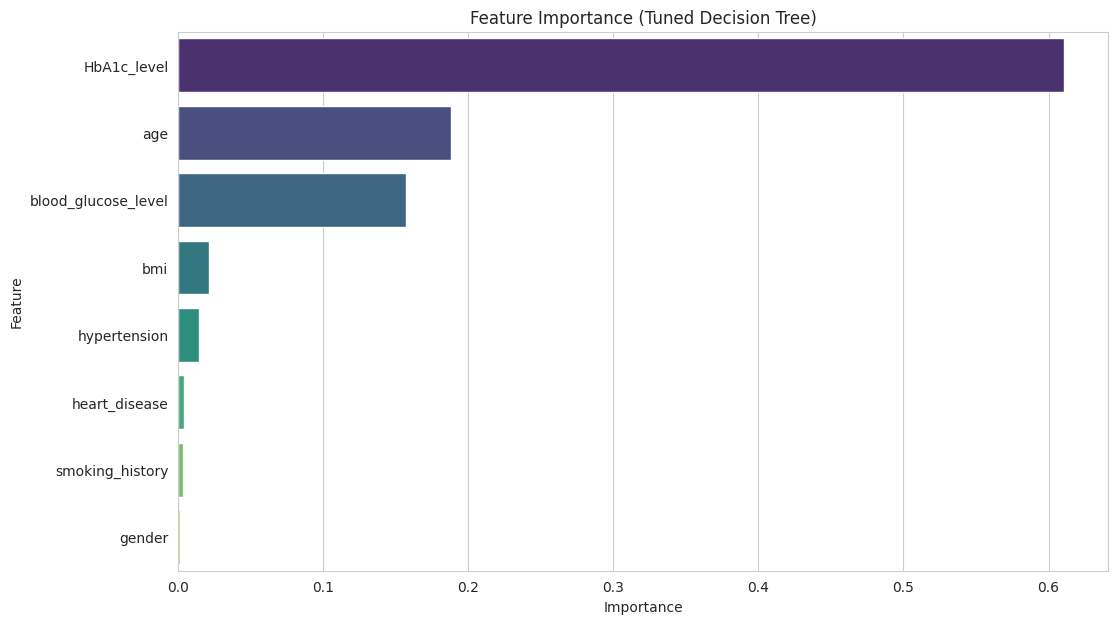

In [12]:
#=======================================================
#Step 8:Feature Importance and Tree Visualization
#=======================================================

print("\n--- Plotting Feature Importance ---")
importances = best_dt.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance (Tuned Decision Tree)')
plt.savefig('tuned_feature_importance.png')
plt.show()